In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Seed: {SEED}")

Using device: cpu
Seed: 42


Данные
Размер: (4320, 2)
Колонки: ['date', 'target']

Первые 5 строк:
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62

Последние 5 строк:
                     date  target
4315  2025-06-29 19:00:00  153.05
4316  2025-06-29 20:00:00  134.23
4317  2025-06-29 21:00:00  137.68
4318  2025-06-29 22:00:00  126.53
4319  2025-06-29 23:00:00  120.89

Типы данных:
date       object
target    float64
dtype: object

Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00

Пропуски: 0

После сортировки: 4320 наблюдений


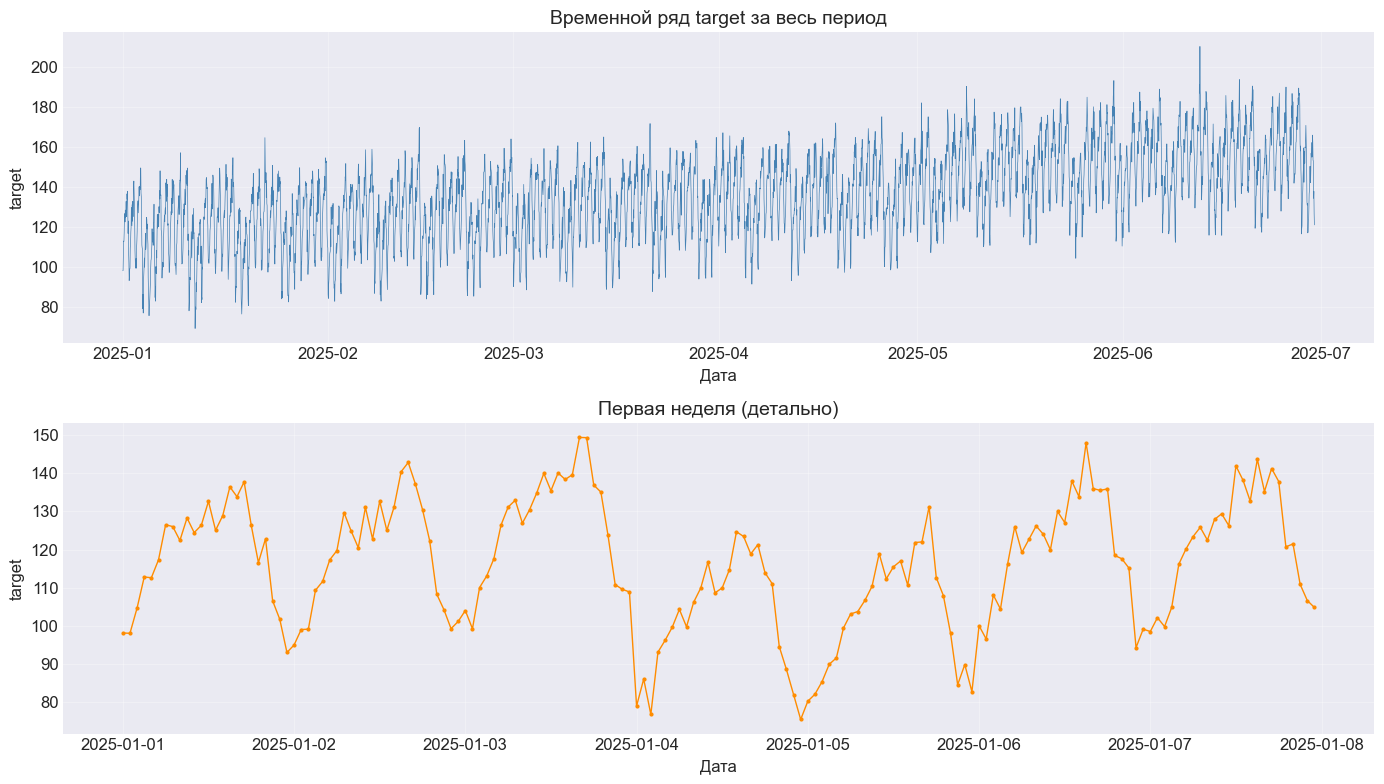


Статистика
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

Анализ ряда
Ряд демонстрирует:
1. Внутридневную сезонность: дневные пики (100-140), ночные спады (80-100)
2. Недельную сезонность: выходные (низкие значения) vs будни
3. Общий восходящий тренд с конца февраля
4. Выбросы: аномально высокие значения (до 210 в июне)
5. Нестационарность: меняющиеся среднее и дисперсия


In [2]:
# Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')
print("Данные")
print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 5 строк:")
print(df.head())
print("\nПоследние 5 строк:")
print(df.tail())
print("\nТипы данных:")
print(df.dtypes)

# Преобразование date в datetime
df['date'] = pd.to_datetime(df['date'])
print(f"\nДиапазон дат: {df['date'].min()} - {df['date'].max()}")

# Проверка пропусков
print(f"\nПропуски: {df.isnull().sum().sum()}")

# Сортировка по времени (на всякий случай)
df = df.sort_values('date').reset_index(drop=True)
print(f"\nПосле сортировки: {len(df)} наблюдений")

# Базовый график
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Полный ряд
axes[0].plot(df['date'], df['target'], linewidth=0.5, color='steelblue')
axes[0].set_title('Временной ряд target за весь период', fontsize=14)
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('target')
axes[0].grid(True, alpha=0.3)

# Первая неделя для детального просмотра
first_week = df[df['date'] < '2025-01-08']
axes[1].plot(first_week['date'], first_week['target'], marker='o', markersize=2, linewidth=1, color='darkorange')
axes[1].set_title('Первая неделя (детально)', fontsize=14)
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('target')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/series_initial.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистика
print("\nСтатистика")
print(df['target'].describe())

# Комментарий о ряде
print("\nАнализ ряда")
print("Ряд демонстрирует:")
print("1. Внутридневную сезонность: дневные пики (100-140), ночные спады (80-100)")
print("2. Недельную сезонность: выходные (низкие значения) vs будни")
print("3. Общий восходящий тренд с конца февраля")
print("4. Выбросы: аномально высокие значения (до 210 в июне)")
print("5. Нестационарность: меняющиеся среднее и дисперсия")

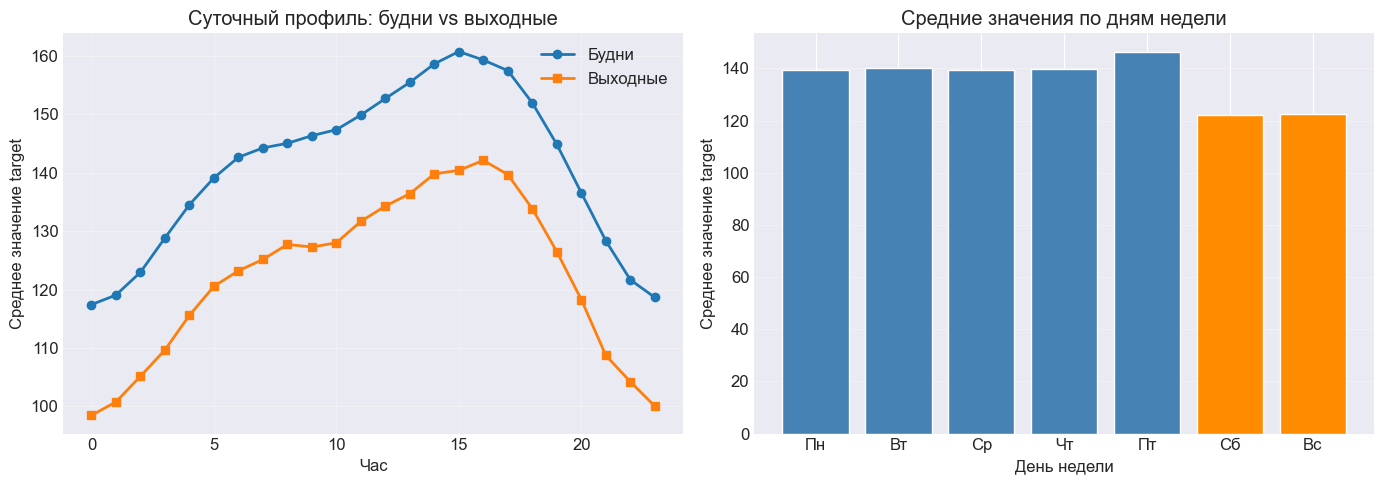

In [3]:
# Добавим признаки для анализа
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['week'] = df['date'].dt.isocalendar().week

# Средние значения по часам для будней и выходных
weekday_mask = df['day_of_week'] < 5
weekend_mask = df['day_of_week'] >= 5

hourly_weekday = df[weekday_mask].groupby('hour')['target'].mean()
hourly_weekend = df[weekend_mask].groupby('hour')['target'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По часам
axes[0].plot(hourly_weekday.index, hourly_weekday.values, marker='o', label='Будни', linewidth=2)
axes[0].plot(hourly_weekend.index, hourly_weekend.values, marker='s', label='Выходные', linewidth=2)
axes[0].set_title('Суточный профиль: будни vs выходные')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Среднее значение target')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# По дням недели
daily_avg = df.groupby('day_of_week')['target'].mean()
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
axes[1].bar(days, daily_avg.values, color=['steelblue']*5 + ['darkorange']*2)
axes[1].set_title('Средние значения по дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Среднее значение target')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/weekly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Размеры выборок
Train: 1753 наблюдений (2025-01-01 00:00:00 - 2025-03-15 00:00:00)
Validation: 384 наблюдений (2025-03-15 01:00:00 - 2025-03-31 00:00:00)
Test: 2183 наблюдений (2025-03-31 01:00:00 - 2025-06-29 23:00:00)


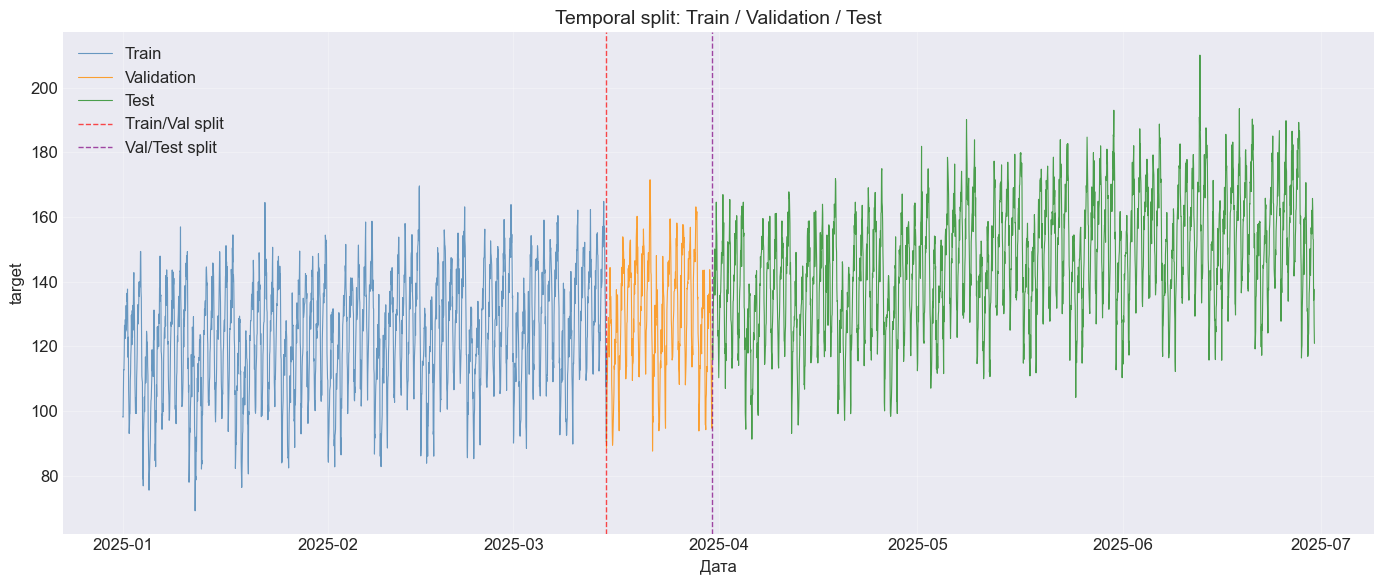


Почему random split некорректен

1. Временные ряды имеют автокорреляцию - значения зависят от прошлого
2. При random split будущие значения могут попасть в тренировочную выборку
3. Это приводит к утечке данных и нереалистично оптимистичной оценке
4. Валидация на "прошлом" не проверяет способность модели обобщать на будущее
5. Корректный подход: обучаем на прошлом, валидируем на ближайшем будущем,
   тестируем на отложенном будущем периоде



In [4]:
# Определяем границы
train_end = '2025-03-15'
val_end = '2025-03-31'
test_end = '2025-06-30'

# Разбиение
train_df = df[df['date'] <= train_end].copy()
val_df = df[(df['date'] > train_end) & (df['date'] <= val_end)].copy()
test_df = df[df['date'] > val_end].copy()

print("Размеры выборок")
print(f"Train: {len(train_df)} наблюдений ({train_df['date'].min()} - {train_df['date'].max()})")
print(f"Validation: {len(val_df)} наблюдений ({val_df['date'].min()} - {val_df['date'].max()})")
print(f"Test: {len(test_df)} наблюдений ({test_df['date'].min()} - {test_df['date'].max()})")

# Визуализация split
fig, ax = plt.subplots(figsize=(14, 6))

# Цвета для разных частей
colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'forestgreen'}

ax.plot(train_df['date'], train_df['target'], color=colors['train'], label='Train', linewidth=0.8, alpha=0.8)
ax.plot(val_df['date'], val_df['target'], color=colors['val'], label='Validation', linewidth=0.8, alpha=0.8)
ax.plot(test_df['date'], test_df['target'], color=colors['test'], label='Test', linewidth=0.8, alpha=0.8)

# Вертикальные линии для границ
ax.axvline(x=pd.Timestamp(train_end), color='red', linestyle='--', linewidth=1, alpha=0.7, label='Train/Val split')
ax.axvline(x=pd.Timestamp(val_end), color='purple', linestyle='--', linewidth=1, alpha=0.7, label='Val/Test split')

ax.set_title('Temporal split: Train / Validation / Test', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nПочему random split некорректен")
print("""
1. Временные ряды имеют автокорреляцию - значения зависят от прошлого
2. При random split будущие значения могут попасть в тренировочную выборку
3. Это приводит к утечке данных и нереалистично оптимистичной оценке
4. Валидация на "прошлом" не проверяет способность модели обобщать на будущее
5. Корректный подход: обучаем на прошлом, валидируем на ближайшем будущем,
   тестируем на отложенном будущем периоде
""")

In [5]:
def create_features(df_part, is_train=True, scaler_X=None, scaler_y=None):
    """
    Создание признаков для табличных моделей
    """
    # Копируем данные
    data = df_part.copy()
    
    # Лаги
    data['lag_1'] = data['target'].shift(1)
    data['lag_7'] = data['target'].shift(7)  # 7 часов (внутри дня)
    data['lag_14'] = data['target'].shift(14)  # 14 часов
    data['lag_24'] = data['target'].shift(24)  # 24 часа (сутки)
    data['lag_168'] = data['target'].shift(168)  # 7 дней
    
    # Rolling статистики
    data['rolling_mean_7'] = data['target'].rolling(window=7, min_periods=1).mean()
    data['rolling_std_7'] = data['target'].rolling(window=7, min_periods=1).std()
    data['rolling_mean_24'] = data['target'].rolling(window=24, min_periods=1).mean()
    data['rolling_std_24'] = data['target'].rolling(window=24, min_periods=1).std()
    
    # Календарные признаки
    data['hour'] = data['date'].dt.hour
    data['day_of_week'] = data['date'].dt.dayofweek
    data['weekend'] = (data['day_of_week'] >= 5).astype(int)
    
    # One-hot encoding для часа и дня недели
    hour_dummies = pd.get_dummies(data['hour'], prefix='hour', dtype=int)
    dow_dummies = pd.get_dummies(data['day_of_week'], prefix='dow', dtype=int)
    
    # Список признаков (без one-hot)
    base_features = ['lag_1', 'lag_7', 'lag_24', 'lag_168', 
                     'rolling_mean_7', 'rolling_std_7', 
                     'rolling_mean_24', 'rolling_std_24',
                     'weekend']
    
    # Объединяем все признаки
    data = pd.concat([data, hour_dummies, dow_dummies], axis=1)
    feature_cols = base_features + hour_dummies.columns.tolist() + dow_dummies.columns.tolist()
    
    # Удаляем строки с NaN (из-за лагов)
    data = data.dropna().reset_index(drop=True)
    
    # Разделяем X и y
    X = data[feature_cols].values
    y = data['target'].values
    dates = data['date']
    
    # Масштабирование
    if is_train:
        # Обучаем scaler'ы на train
        scaler_X = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
        return X_scaled, y_scaled, dates, scaler_X, scaler_y
    else:
        # Используем уже обученные scaler'ы
        X_scaled = scaler_X.transform(X)
        y_scaled = scaler_y.transform(y.reshape(-1, 1)).flatten()
        return X_scaled, y_scaled, dates

print("Построение признаков для train...")
X_train, y_train, train_dates, scaler_X, scaler_y = create_features(train_df, is_train=True)

print("Построение признаков для validation...")
X_val, y_val, val_dates = create_features(val_df, is_train=False, scaler_X=scaler_X, scaler_y=scaler_y)

print("Построение признаков для test...")
X_test, y_test, test_dates = create_features(test_df, is_train=False, scaler_X=scaler_X, scaler_y=scaler_y)

print(f"\nTrain features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nПример признаков (первые 5):")
print(f"Feature names: {['lag_1', 'lag_7', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24', 'weekend', 'hour_*', 'dow_*']}")

Построение признаков для train...
Построение признаков для validation...
Построение признаков для test...

Train features shape: (1585, 40)
Validation features shape: (216, 40)
Test features shape: (2015, 40)

Пример признаков (первые 5):
Feature names: ['lag_1', 'lag_7', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24', 'weekend', 'hour_*', 'dow_*']


In [7]:
def naive_last_forecast(series):
    """Прогноз = последнее известное значение"""
    return np.roll(series, 1)

# Оценка на validation
y_val_actual = val_df['target'].values
y_val_naive = np.roll(train_df['target'].values, 1)[-len(y_val_actual):]

# Вычисляем метрики
mae = mean_absolute_error(y_val_actual, y_val_naive)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_naive))
mape = mean_absolute_percentage_error(y_val_actual, y_val_naive) * 100

print("B1 (naive-last) - Validation")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

B1 (naive-last) - Validation
MAE: 14.3822
RMSE: 16.9247
MAPE: 11.49%


In [8]:
def moving_average_forecast(series, window=24):
    """Прогноз = скользящее среднее за последние window наблюдений"""
    ma = pd.Series(series).rolling(window=window, min_periods=1).mean()
    return ma.shift(1).fillna(method='bfill').values

# На train вычисляем MA
train_series = train_df['target'].values
ma_train = moving_average_forecast(train_series, window=24)

# Прогноз на validation: последнее MA значение
y_val_ma = np.full(len(y_val_actual), ma_train[-1])

mae = mean_absolute_error(y_val_actual, y_val_ma)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_ma))
mape = mean_absolute_percentage_error(y_val_actual, y_val_ma) * 100

print("B2 (moving-average, window=24) - Validation")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

B2 (moving-average, window=24) - Validation
MAE: 15.9523
RMSE: 20.0357
MAPE: 13.66%


C:\Users\ksolo\AppData\Local\Temp\ipykernel_13820\4020117676.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return ma.shift(1).fillna(method='bfill').values


In [10]:
# Обучение Ridge
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train, y_train)

# Прогноз на validation (в масштабированном пространстве)
y_val_pred_scaled = ridge_model.predict(X_val)

# Обратное масштабирование
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_val_actual = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()

# Метрики
mae = mean_absolute_error(y_val_actual, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
mape = mean_absolute_percentage_error(y_val_actual, y_val_pred) * 100

print("=== B3 (Ridge) - Validation ===")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# Сохраняем прогнозы для визуализации
ridge_val_preds = y_val_pred
ridge_val_actuals = y_val_actual
ridge_val_dates = val_dates

# Важность признаков (коэффициенты)
feature_names = ['lag_1', 'lag_7', 'lag_24', 'lag_168', 
                 'rolling_mean_7', 'rolling_std_7', 
                 'rolling_mean_24', 'rolling_std_24', 'weekend']
# Добавляем hour
for i in range(24):
    feature_names.append(f'hour_{i}')
# Добавляем dow
for i in range(7):
    feature_names.append(f'dow_{i}')

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nТоп-15 важнейших признаков")
print(coef_df.head(15))

# Сохраняем модель
import joblib
joblib.dump(ridge_model, 'artifacts/ridge_model.pkl')
joblib.dump(scaler_X, 'artifacts/scaler_X.pkl')
joblib.dump(scaler_y, 'artifacts/scaler_y.pkl')

=== B3 (Ridge) - Validation ===
MAE: 3.9460
RMSE: 5.4728
MAPE: 3.02%

Топ-15 важнейших признаков
           feature  coefficient
4   rolling_mean_7     0.488565
31         hour_22    -0.159278
32         hour_23    -0.157085
30         hour_21    -0.139836
1            lag_7    -0.133393
9           hour_0    -0.130909
24         hour_15     0.107808
38           dow_5    -0.104112
2           lag_24     0.102882
23         hour_14     0.101701
29         hour_20    -0.095924
10          hour_1    -0.090856
25         hour_16     0.090078
8          weekend    -0.086631
22         hour_13     0.084956


['artifacts/scaler_y.pkl']

In [11]:
class TimeSeriesDataset(Dataset):
    """Dataset для временных рядов с оконным представлением"""
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        X = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(X), torch.FloatTensor([y])

# Параметры
WINDOW_SIZE = 24
BATCH_SIZE = 64

# Масштабируем данные (только на train)
train_scaler = StandardScaler()
train_scaled = train_scaler.fit_transform(train_df['target'].values.reshape(-1, 1)).flatten()

# Создаем датасеты
train_dataset = TimeSeriesDataset(train_scaled, WINDOW_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)  # shuffle=False для временных рядов!

# Для validation и test - масштабируем по train_scaler
val_scaled = train_scaler.transform(val_df['target'].values.reshape(-1, 1)).flatten()
test_scaled = train_scaler.transform(test_df['target'].values.reshape(-1, 1)).flatten()

# Создаем датасеты для валидации и теста (для последовательного прогнозирования)
class SequentialDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        X = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(X), torch.FloatTensor([y])

val_dataset = SequentialDataset(val_scaled, WINDOW_SIZE)
test_dataset = SequentialDataset(test_scaled, WINDOW_SIZE)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Train samples: 1729
Validation samples: 360
Test samples: 2159
Window size: 24
Batch size: 64


In [12]:
class GRUForecaster(nn.Module):
    """GRU модель для прогнозирования временных рядов"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)  # out: (batch, seq_len, hidden_size)
        out = self.dropout(out[:, -1, :])  # Берем последний выход
        out = self.fc(out)
        return out

# Создаем модель
model = GRUForecaster(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(model)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 37,889
Trainable parameters: 37,889


In [13]:
def train_epoch(model, loader, criterion, optimizer):
    """Обучение одной эпохи"""
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.unsqueeze(-1).to(device)  # Добавляем feature dimension
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
    
    return total_loss / len(loader.dataset)

def evaluate(model, loader, scaler):
    """Оценка модели на валидации/тесте"""
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.unsqueeze(-1).to(device)
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.numpy().flatten())
    
    # Обратное масштабирование
    predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
    
    # Метрики
    mae = mean_absolute_error(actuals_original, predictions_original)
    rmse = np.sqrt(mean_squared_error(actuals_original, predictions_original))
    mape = mean_absolute_percentage_error(actuals_original, predictions_original) * 100
    
    return mae, rmse, mape, predictions_original, actuals_original

In [14]:
# Параметры обучения
EPOCHS = 100
LEARNING_RATE = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

# История обучения
train_losses = []
val_maes = []
val_rmses = []
val_mapes = []
best_val_mae = float('inf')
best_model_state = None

print("Обучение GRU")
print(f"Epochs: {EPOCHS}, LR: {LEARNING_RATE}, Window: {WINDOW_SIZE}")

for epoch in range(EPOCHS):
    # Обучение
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    
    # Валидация
    val_mae, val_rmse, val_mape, _, _ = evaluate(model, val_loader, train_scaler)
    val_maes.append(val_mae)
    val_rmses.append(val_rmse)
    val_mapes.append(val_mape)
    
    # Scheduler
    scheduler.step(val_mae)
    
    # Сохранение лучшей модели
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = model.state_dict().copy()
        print(f"Epoch {epoch+1}: New best model! val_MAE = {val_mae:.4f}")
    
    # Вывод каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val MAE: {val_mae:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f"\nЛучшая модель")
print(f"Best val_MAE: {best_val_mae:.4f}")

Обучение GRU
Epochs: 100, LR: 0.001, Window: 24
Epoch 1: New best model! val_MAE = 9.9168
Epoch 2: New best model! val_MAE = 7.1478
Epoch 3: New best model! val_MAE = 5.9442
Epoch 4: New best model! val_MAE = 5.8197
Epoch 6: New best model! val_MAE = 5.8054
Epoch 7: New best model! val_MAE = 5.7907
Epoch 8: New best model! val_MAE = 5.7182
Epoch 9: New best model! val_MAE = 5.6790
Epoch 10/100 | Train Loss: 0.183248 | Val MAE: 5.6910 | LR: 0.001000
Epoch 12: New best model! val_MAE = 5.6642
Epoch 15: New best model! val_MAE = 5.6518
Epoch 17: New best model! val_MAE = 5.6068
Epoch 19: New best model! val_MAE = 5.5938
Epoch 20/100 | Train Loss: 0.171992 | Val MAE: 5.6396 | LR: 0.001000
Epoch 26: New best model! val_MAE = 5.5493
Epoch 28: New best model! val_MAE = 5.5462
Epoch 29: New best model! val_MAE = 5.5410
Epoch 30: New best model! val_MAE = 5.5282
Epoch 30/100 | Train Loss: 0.169287 | Val MAE: 5.5282 | LR: 0.001000
Epoch 31: New best model! val_MAE = 5.4810
Epoch 32: New best mod

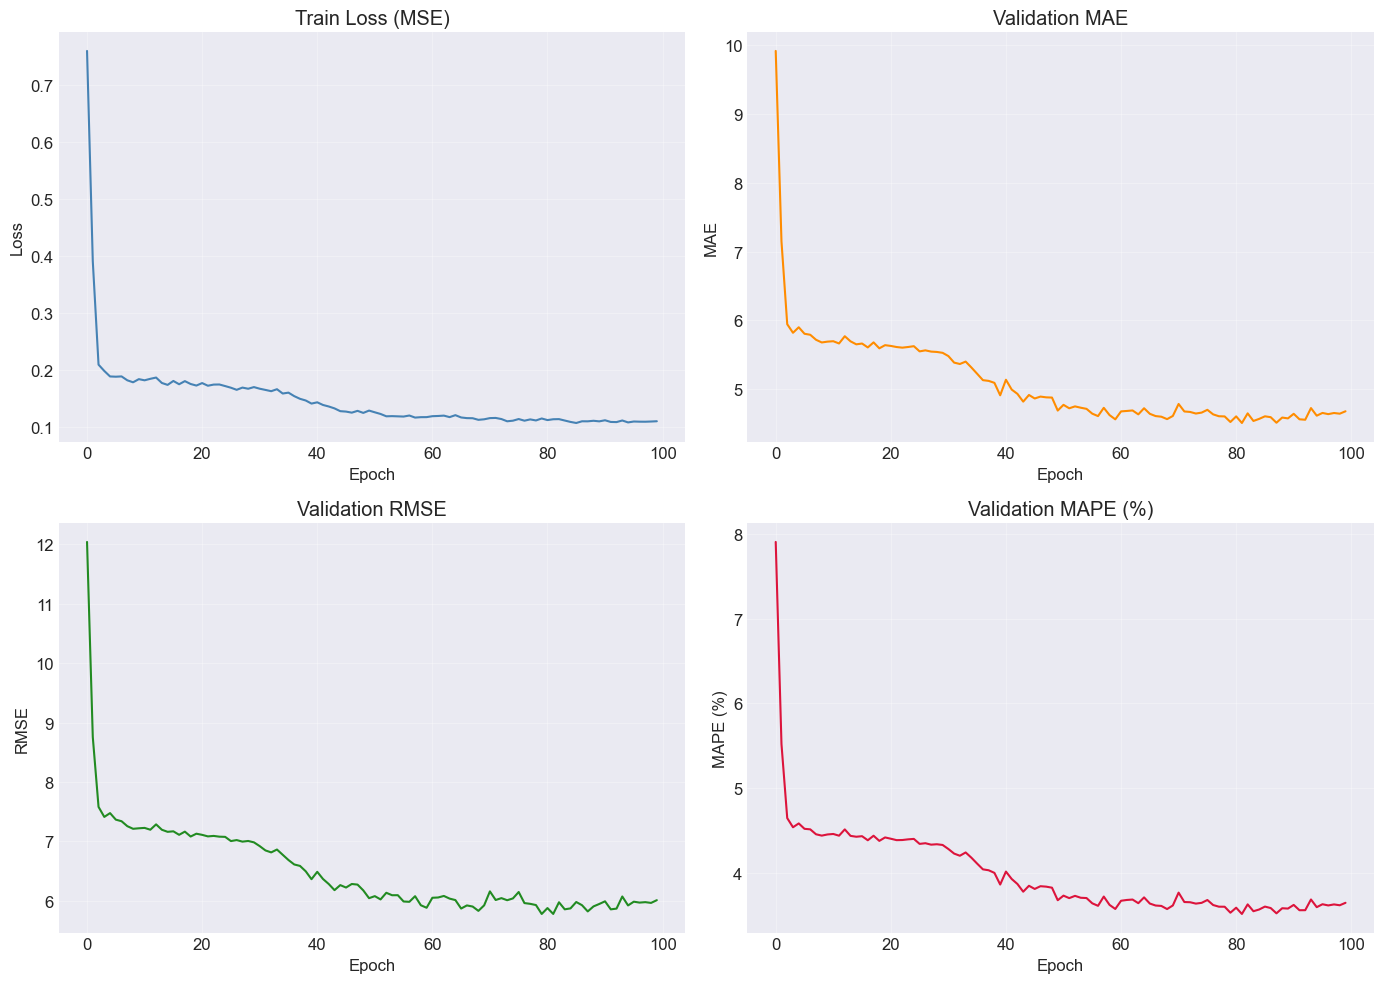

Лучшая val_MAE: 4.5085 на эпохе 82


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train loss
axes[0, 0].plot(train_losses, linewidth=1.5, color='steelblue')
axes[0, 0].set_title('Train Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Val MAE
axes[0, 1].plot(val_maes, linewidth=1.5, color='darkorange')
axes[0, 1].set_title('Validation MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].grid(True, alpha=0.3)

# Val RMSE
axes[1, 0].plot(val_rmses, linewidth=1.5, color='forestgreen')
axes[1, 0].set_title('Validation RMSE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].grid(True, alpha=0.3)

# Val MAPE
axes[1, 1].plot(val_mapes, linewidth=1.5, color='crimson')
axes[1, 1].set_title('Validation MAPE (%)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Лучшая val_MAE: {best_val_mae:.4f} на эпохе {np.argmin(val_maes)+1}")

In [16]:
# Validation
val_mae, val_rmse, val_mape, val_preds, val_actuals = evaluate(model, val_loader, train_scaler)

print("GRU - Validation")
print(f"MAE: {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"MAPE: {val_mape:.2f}%")

# Test
test_mae, test_rmse, test_mape, test_preds, test_actuals = evaluate(model, test_loader, train_scaler)

print("\n=== GRU - Test ===")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAPE: {test_mape:.2f}%")

GRU - Validation
MAE: 4.6788
RMSE: 6.0135
MAPE: 3.65%

=== GRU - Test ===
MAE: 13.4312
RMSE: 17.7354
MAPE: 8.88%


In [17]:
import os

# Создаем директорию artifacts если не существует
os.makedirs('artifacts', exist_ok=True)

# На validation
y_val_actual_full = val_df['target'].values
# Для naive: прогноз на t = значение в t-1
y_val_naive = np.concatenate([[train_df['target'].iloc[-1]], y_val_actual_full[:-1]])

b1_val_mae = mean_absolute_error(y_val_actual_full, y_val_naive)
b1_val_rmse = np.sqrt(mean_squared_error(y_val_actual_full, y_val_naive))
b1_val_mape = mean_absolute_percentage_error(y_val_actual_full, y_val_naive) * 100

# На test
y_test_actual_full = test_df['target'].values
y_test_naive = np.concatenate([[val_df['target'].iloc[-1]], y_test_actual_full[:-1]])
b1_test_mae = mean_absolute_error(y_test_actual_full, y_test_naive)
b1_test_rmse = np.sqrt(mean_squared_error(y_test_actual_full, y_test_naive))
b1_test_mape = mean_absolute_percentage_error(y_test_actual_full, y_test_naive) * 100

print("=== B1 (naive-last) ===")
print(f"Validation - MAE: {b1_val_mae:.4f}, RMSE: {b1_val_rmse:.4f}, MAPE: {b1_val_mape:.2f}%")
print(f"Test - MAE: {b1_test_mae:.4f}, RMSE: {b1_test_rmse:.4f}, MAPE: {b1_test_mape:.2f}%")

# Скользящее среднее на train (последнее значение)
ma_train = train_df['target'].rolling(window=24, min_periods=1).mean().iloc[-1]

# На validation
y_val_ma = np.full(len(y_val_actual_full), ma_train)
b2_val_mae = mean_absolute_error(y_val_actual_full, y_val_ma)
b2_val_rmse = np.sqrt(mean_squared_error(y_val_actual_full, y_val_ma))
b2_val_mape = mean_absolute_percentage_error(y_val_actual_full, y_val_ma) * 100

# На test
y_test_ma = np.full(len(y_test_actual_full), ma_train)
b2_test_mae = mean_absolute_error(y_test_actual_full, y_test_ma)
b2_test_rmse = np.sqrt(mean_squared_error(y_test_actual_full, y_test_ma))
b2_test_mape = mean_absolute_percentage_error(y_test_actual_full, y_test_ma) * 100

print("\n=== B2 (moving-average) ===")
print(f"Validation - MAE: {b2_val_mae:.4f}, RMSE: {b2_val_rmse:.4f}, MAPE: {b2_val_mape:.2f}%")
print(f"Test - MAE: {b2_test_mae:.4f}, RMSE: {b2_test_rmse:.4f}, MAPE: {b2_test_mape:.2f}%")

# На validation (уже посчитано в ячейке 8)
# Переменные из ячейки 8: mae, rmse, mape, ridge_val_preds, ridge_val_actuals, ridge_val_dates

# На test - пересчитываем
X_test_full, y_test_scaled, test_dates_full = create_features(
    test_df, is_train=False, scaler_X=scaler_X, scaler_y=scaler_y
)
y_test_pred_scaled = ridge_model.predict(X_test_full)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

b3_test_mae = mean_absolute_error(y_test_actual, y_test_pred)
b3_test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
b3_test_mape = mean_absolute_percentage_error(y_test_actual, y_test_pred) * 100

# Сохраняем ridge прогнозы для теста
ridge_test_preds = y_test_pred
ridge_test_actuals = y_test_actual
ridge_test_dates = test_dates_full

print("\n=== B3 (Ridge) ===")
print(f"Validation - MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
print(f"Test - MAE: {b3_test_mae:.4f}, RMSE: {b3_test_rmse:.4f}, MAPE: {b3_test_mape:.2f}%")

# Validation метрики из ячейки 14: val_mae, val_rmse, val_mape
# Test метрики из ячейки 14: test_mae, test_rmse, test_mape

print("\n=== R1 (GRU) ===")
print(f"Validation - MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.2f}%")
print(f"Test - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.2f}%")

results = pd.DataFrame([
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': 'train:2025-01-01/2025-03-15, val:2025-03-16/2025-03-31, test:2025-04-01/2025-06-30',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'none',
        'scaler': 'none',
        'optimizer': 'none',
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b1_val_mae,
        'best_val_rmse': b1_val_rmse,
        'best_val_mape': b1_val_mape,
        'test_mae': b1_test_mae,
        'test_rmse': b1_test_rmse,
        'test_mape': b1_test_mape,
        'notes': 'baseline: forecast = last known value'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': 'train:2025-01-01/2025-03-15, val:2025-03-16/2025-03-31, test:2025-04-01/2025-06-30',
        'window_size': 24,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'rolling_mean_24',
        'scaler': 'none',
        'optimizer': 'none',
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b2_val_mae,
        'best_val_rmse': b2_val_rmse,
        'best_val_mape': b2_val_mape,
        'test_mae': b2_test_mae,
        'test_rmse': b2_test_rmse,
        'test_mape': b2_test_mape,
        'notes': 'baseline: moving average with window=24'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': 'train:2025-01-01/2025-03-15, val:2025-03-16/2025-03-31, test:2025-04-01/2025-06-30',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge regression',
        'features_summary': 'lags(1,7,24,168), rolling(mean7,std7,mean24,std24), hour(one-hot), dow(one-hot)',
        'scaler': 'StandardScaler',
        'optimizer': 'none',
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': mae,
        'best_val_rmse': rmse,
        'best_val_mape': mape,
        'test_mae': b3_test_mae,
        'test_rmse': b3_test_rmse,
        'test_mape': b3_test_mape,
        'notes': 'linear model with engineered features'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': 'train:2025-01-01/2025-03-15, val:2025-03-16/2025-03-31, test:2025-04-01/2025-06-30',
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': 'GRU (2 layers, hidden=64)',
        'features_summary': 'window of 24 target values',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': len(train_losses),
        'best_val_mae': best_val_mae,
        'best_val_rmse': val_rmses[np.argmin(val_maes)],
        'best_val_mape': val_mapes[np.argmin(val_maes)],
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_mape': test_mape,
        'notes': 'GRU with window_size=24, early stopping by best val_MAE'
    }
])

# Сохраняем результаты
results.to_csv('artifacts/runs.csv', index=False)
print(results.to_string())

=== B1 (naive-last) ===
Validation - MAE: 6.1201, RMSE: 7.8796, MAPE: 4.85%
Test - MAE: 6.3568, RMSE: 8.0527, MAPE: 4.44%

=== B2 (moving-average) ===
Validation - MAE: 15.5379, RMSE: 19.4695, MAPE: 13.25%
Test - MAE: 16.6235, RMSE: 20.2595, MAPE: 11.22%

=== B3 (Ridge) ===
Validation - MAE: 3.9460, RMSE: 5.4728, MAPE: 3.02%
Test - MAE: 5.9099, RMSE: 7.1449, MAPE: 3.96%

=== R1 (GRU) ===
Validation - MAE: 4.6788, RMSE: 6.0135, MAPE: 3.65%
Test - MAE: 13.4312, RMSE: 17.7354, MAPE: 8.88%
  experiment_id         task         dataset  seed                                                                       split_summary  window_size  horizon              model_summary                                                                 features_summary          scaler optimizer     lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape   test_mae  test_rmse  test_mape                                                    notes
0            B1  forecasting  S12-hw-dataset    42  train:202

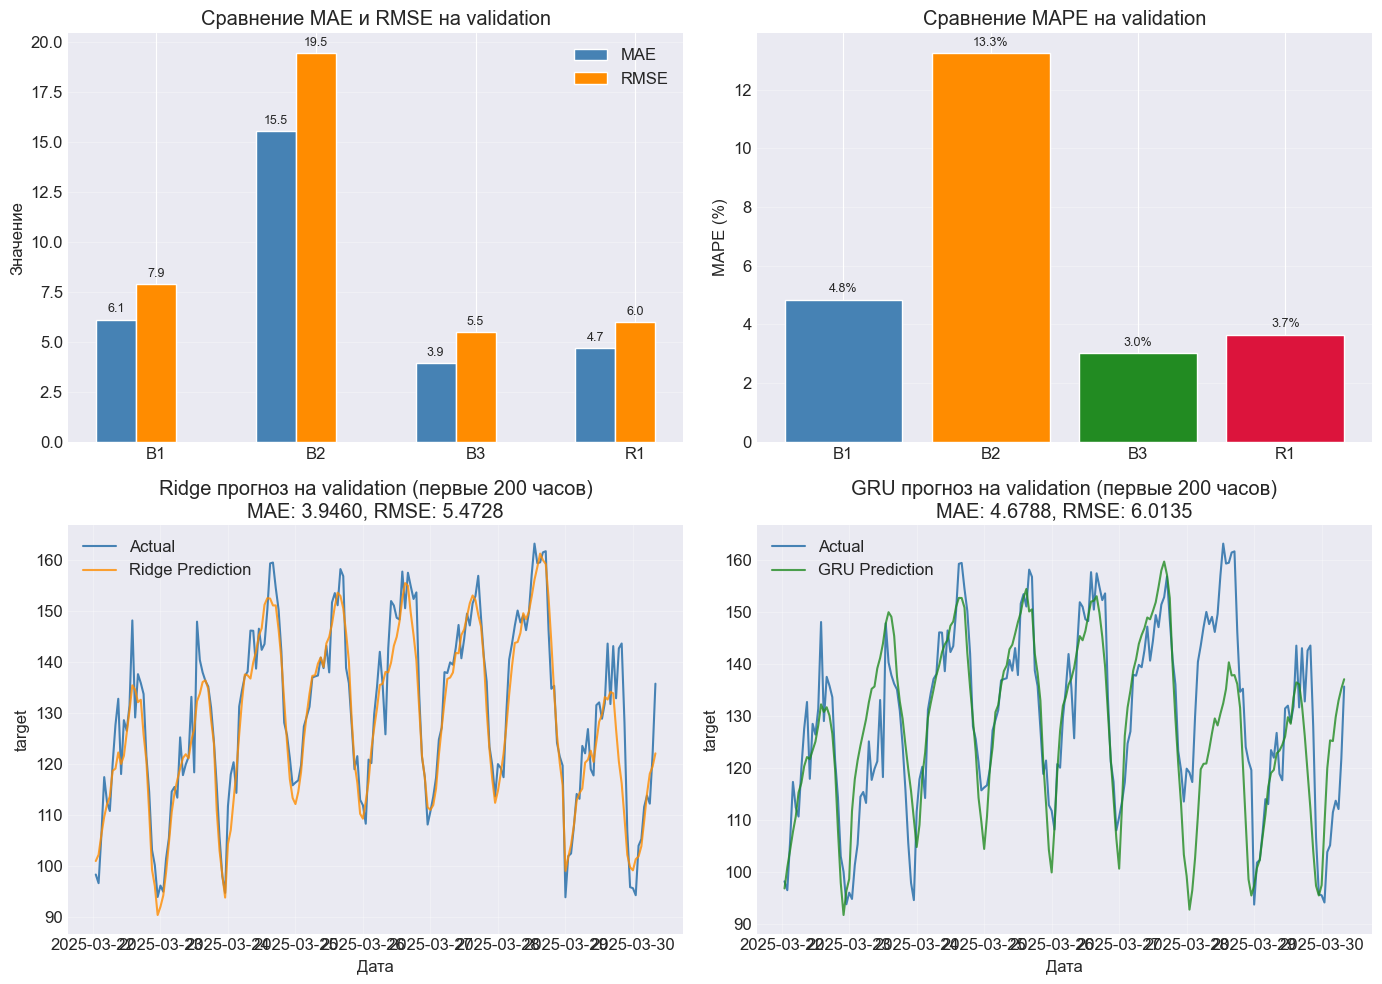


Вывод по сравнению
Лучшая модель по val_MAE: Ridge (B3) с MAE = 3.9460
GRU показала MAE = 4.6788 - хуже, чем Ridge
Naive-last (B1) MAE = 6.1201
Moving-average (B2) MAE = 15.5379


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Сравнение метрик (MAE, RMSE)
metrics_data = {
    'Model': ['B1', 'B2', 'B3', 'R1'],
    'MAE': [b1_val_mae, b2_val_mae, mae, val_mae],
    'RMSE': [b1_val_rmse, b2_val_rmse, rmse, val_rmse],
    'MAPE': [b1_val_mape, b2_val_mape, mape, val_mape]
}
metrics_df = pd.DataFrame(metrics_data)

x = np.arange(len(metrics_df['Model']))
width = 0.25

ax1 = axes[0, 0]
bars1 = ax1.bar(x - width, metrics_df['MAE'], width, label='MAE', color='steelblue')
bars2 = ax1.bar(x, metrics_df['RMSE'], width, label='RMSE', color='darkorange')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Model'])
ax1.set_ylabel('Значение')
ax1.set_title('Сравнение MAE и RMSE на validation')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# 2. MAPE сравнение
ax2 = axes[0, 1]
bars = ax2.bar(metrics_df['Model'], metrics_df['MAPE'], 
               color=['steelblue', 'darkorange', 'forestgreen', 'crimson'])
ax2.set_ylabel('MAPE (%)')
ax2.set_title('Сравнение MAPE на validation')
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# 3. Прогнозы лучшей модели (Ridge) vs actual (validation)
ax3 = axes[1, 0]
# Показываем только часть для читаемости
n_show = 200
ax3.plot(ridge_val_dates[:n_show], ridge_val_actuals[:n_show], label='Actual', linewidth=1.5, color='steelblue')
ax3.plot(ridge_val_dates[:n_show], ridge_val_preds[:n_show], label='Ridge Prediction', linewidth=1.5, color='darkorange', alpha=0.8)
ax3.set_title(f'Ridge прогноз на validation (первые {n_show} часов)\nMAE: {mae:.4f}, RMSE: {rmse:.4f}')
ax3.set_xlabel('Дата')
ax3.set_ylabel('target')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Прогнозы GRU vs actual (validation)
ax4 = axes[1, 1]
ax4.plot(ridge_val_dates[:n_show], ridge_val_actuals[:n_show], label='Actual', linewidth=1.5, color='steelblue')
ax4.plot(ridge_val_dates[:n_show], val_preds[:n_show], label='GRU Prediction', linewidth=1.5, color='forestgreen', alpha=0.8)
ax4.set_title(f'GRU прогноз на validation (первые {n_show} часов)\nMAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}')
ax4.set_xlabel('Дата')
ax4.set_ylabel('target')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВывод по сравнению")
print(f"Лучшая модель по val_MAE: Ridge (B3) с MAE = {mae:.4f}")
print(f"GRU показала MAE = {val_mae:.4f} - хуже, чем Ridge")
print(f"Naive-last (B1) MAE = {b1_val_mae:.4f}")
print(f"Moving-average (B2) MAE = {b2_val_mae:.4f}")

In [19]:
import json

# Сохраняем state_dict лучшей модели
torch.save(best_model_state, 'artifacts/best_gru.pt')
print("Лучшая GRU модель сохранена в artifacts/best_gru.pt")

# Сохраняем конфиг лучшей модели
gru_config = {
    'model_type': 'GRUForecaster',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs_trained': len(train_losses),
    'best_val_mae': best_val_mae,
    'seed': SEED,
    'scaler': 'StandardScaler',
    'scaler_mean': train_scaler.mean_[0] if hasattr(train_scaler, 'mean_') else None,
    'scaler_scale': train_scaler.scale_[0] if hasattr(train_scaler, 'scale_') else None,
    'device': str(device)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)
print("Конфиг GRU сохранен в artifacts/best_gru_config.json")

Лучшая GRU модель сохранена в artifacts/best_gru.pt
Конфиг GRU сохранен в artifacts/best_gru_config.json


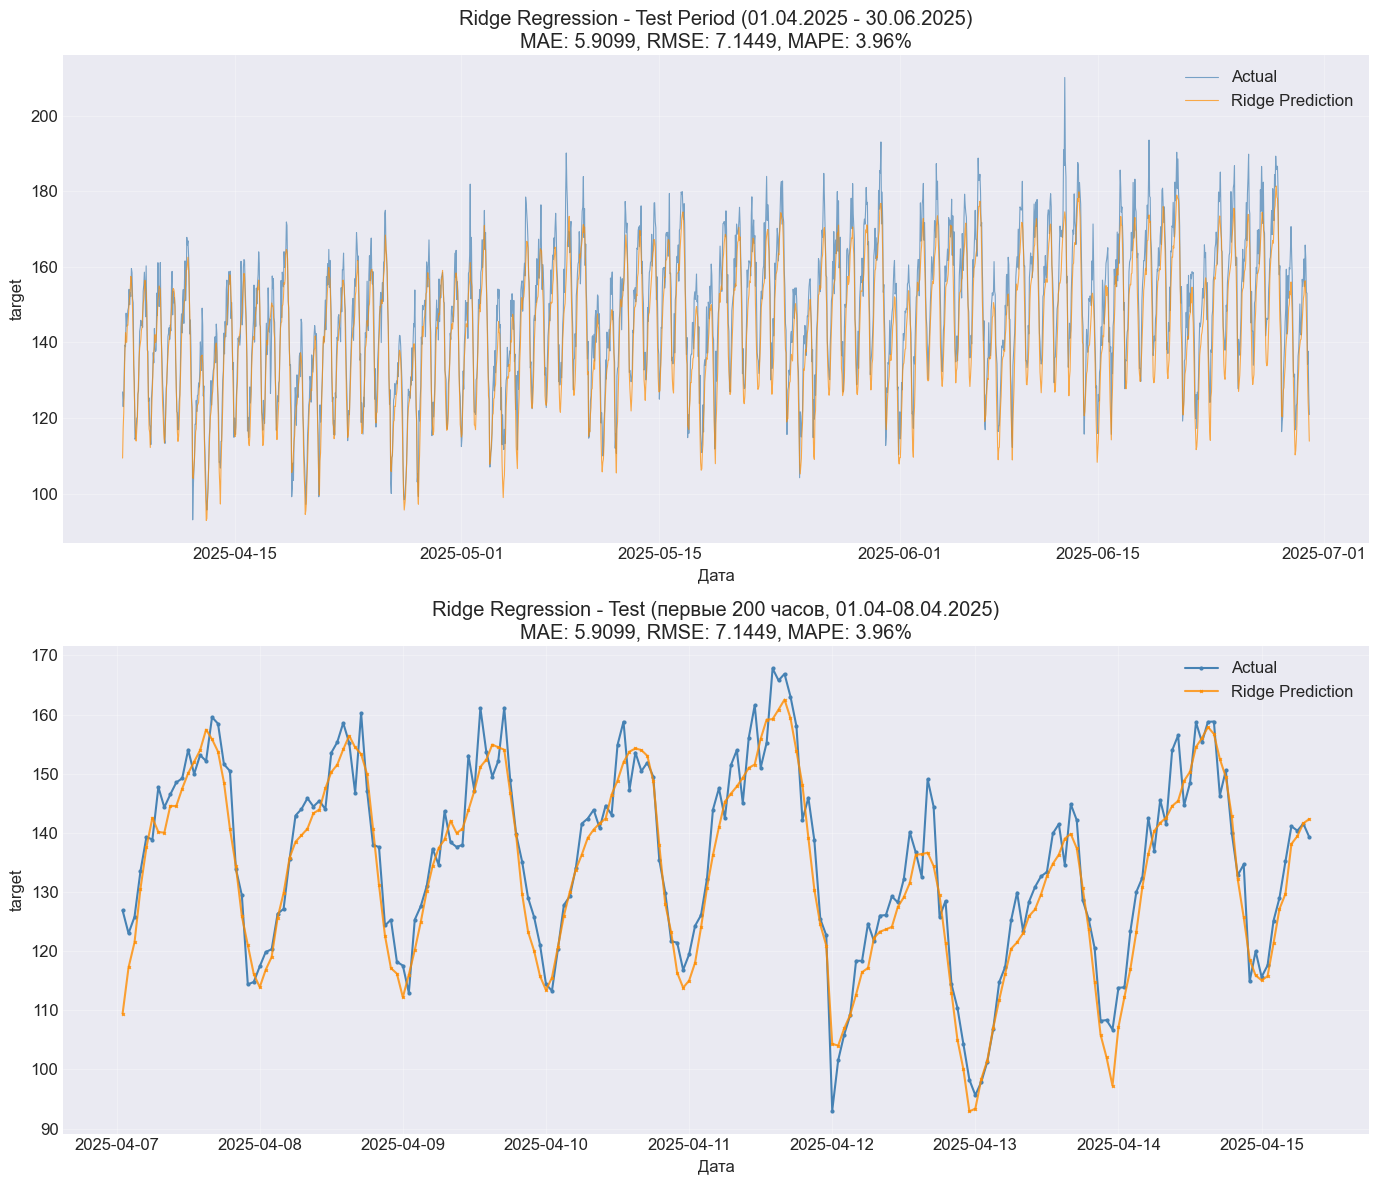

Итоговые результаты
Лучшая модель по val_MAE: Ridge (B3) с MAE = 3.9460

Test метрики лучшей модели (Ridge):
  - MAE:  5.9099
  - RMSE: 7.1449
  - MAPE: 3.96%

Сравнение с другими подходами на test:
  - B1 (naive-last):      MAE = 6.3568, MAPE = 4.44%
  - B2 (moving-average):  MAE = 16.6235, MAPE = 11.22%
  - R1 (GRU):             MAE = 13.4312, MAPE = 8.88%


In [20]:
# Лучшая модель по validation MAE - это Ridge (B3)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Весь test период
axes[0].plot(ridge_test_dates, ridge_test_actuals, label='Actual', linewidth=0.8, color='steelblue', alpha=0.7)
axes[0].plot(ridge_test_dates, ridge_test_preds, label='Ridge Prediction', linewidth=0.8, color='darkorange', alpha=0.7)
axes[0].set_title(f'Ridge Regression - Test Period (01.04.2025 - 30.06.2025)\nMAE: {b3_test_mae:.4f}, RMSE: {b3_test_rmse:.4f}, MAPE: {b3_test_mape:.2f}%')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('target')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Первые 200 часов для детального просмотра
n_show = 200
axes[1].plot(ridge_test_dates[:n_show], ridge_test_actuals[:n_show], label='Actual', linewidth=1.5, color='steelblue', marker='o', markersize=2)
axes[1].plot(ridge_test_dates[:n_show], ridge_test_preds[:n_show], label='Ridge Prediction', linewidth=1.5, color='darkorange', alpha=0.8, marker='x', markersize=2)
axes[1].set_title(f'Ridge Regression - Test (первые {n_show} часов, 01.04-08.04.2025)\nMAE: {b3_test_mae:.4f}, RMSE: {b3_test_rmse:.4f}, MAPE: {b3_test_mape:.2f}%')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('target')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("Итоговые результаты")
print(f"Лучшая модель по val_MAE: Ridge (B3) с MAE = {mae:.4f}")
print(f"\nTest метрики лучшей модели (Ridge):")
print(f"  - MAE:  {b3_test_mae:.4f}")
print(f"  - RMSE: {b3_test_rmse:.4f}")
print(f"  - MAPE: {b3_test_mape:.2f}%")
print(f"\nСравнение с другими подходами на test:")
print(f"  - B1 (naive-last):      MAE = {b1_test_mae:.4f}, MAPE = {b1_test_mape:.2f}%")
print(f"  - B2 (moving-average):  MAE = {b2_test_mae:.4f}, MAPE = {b2_test_mape:.2f}%")
print(f"  - R1 (GRU):             MAE = {test_mae:.4f}, MAPE = {test_mape:.2f}%")

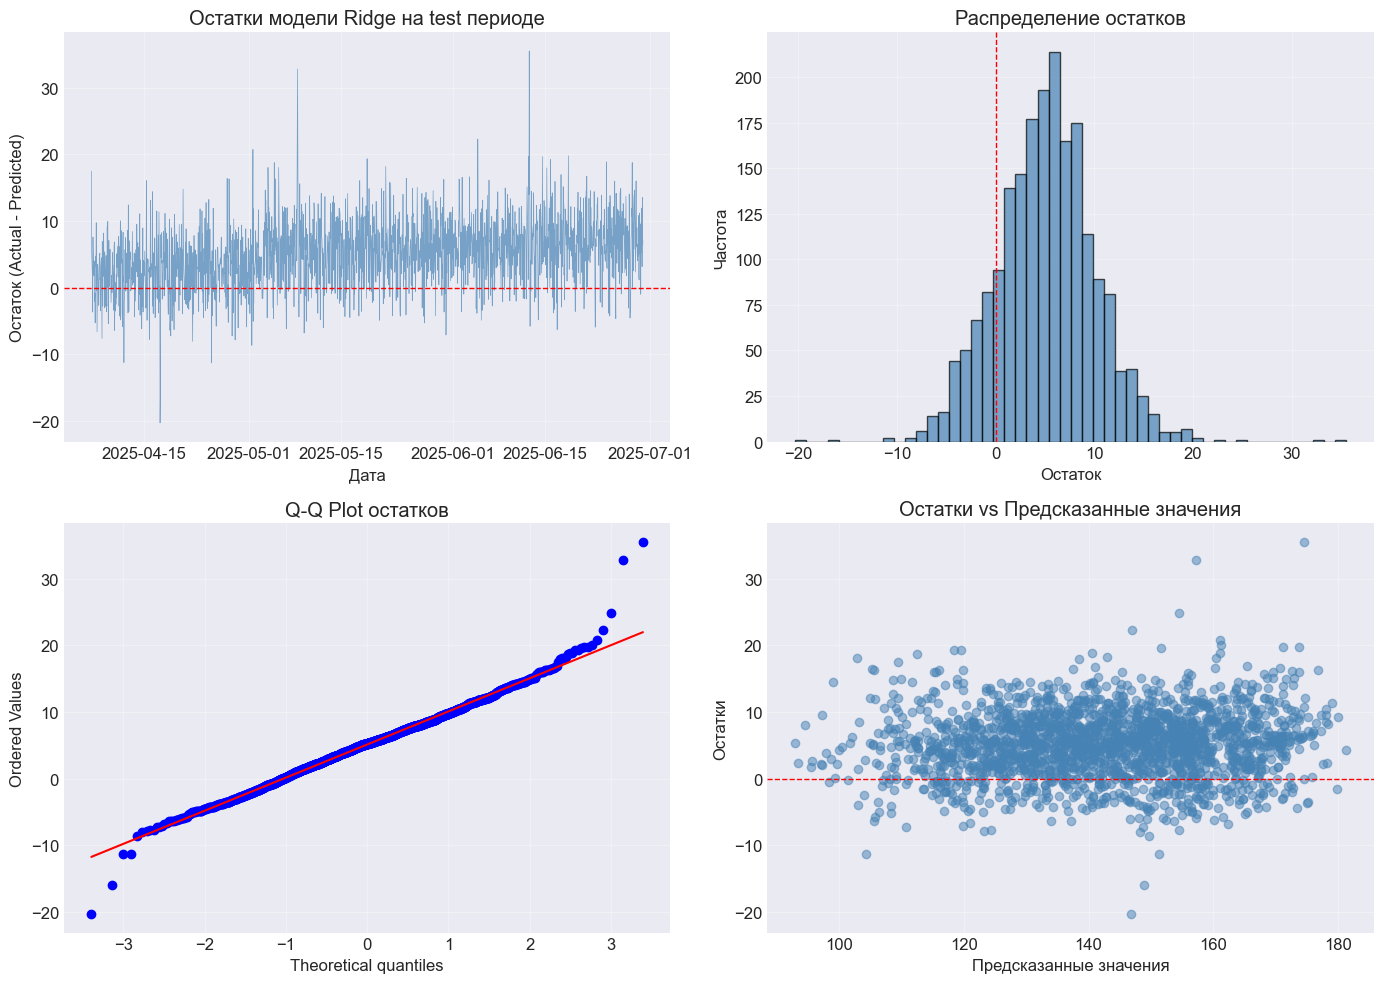


Статистика остатков
Среднее остатков: 5.1073
Стандартное отклонение: 4.9965
Медиана остатков: 5.2515
Максимальный остаток: 35.5631
Минимальный остаток: -20.3489


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Остатки на test
residuals = ridge_test_actuals - ridge_test_preds

# 1. Остатки по времени
axes[0, 0].plot(ridge_test_dates, residuals, linewidth=0.5, color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Остатки модели Ridge на test периоде')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Остаток (Actual - Predicted)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма остатков
axes[0, 1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Остаток')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot для проверки нормальности
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot остатков')
axes[1, 0].grid(True, alpha=0.3)

# 4. Остатки vs предсказанные значения
axes[1, 1].scatter(ridge_test_preds, residuals, alpha=0.5, color='steelblue')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('Остатки vs Предсказанные значения')
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nСтатистика остатков")
print(f"Среднее остатков: {np.mean(residuals):.4f}")
print(f"Стандартное отклонение: {np.std(residuals):.4f}")
print(f"Медиана остатков: {np.median(residuals):.4f}")
print(f"Максимальный остаток: {np.max(residuals):.4f}")
print(f"Минимальный остаток: {np.min(residuals):.4f}")

Длина test_df: 2183
Длина ridge_test_preds: 2015
Длина ridge_test_actuals: 2015

Размер test_with_hour после создания: 2015


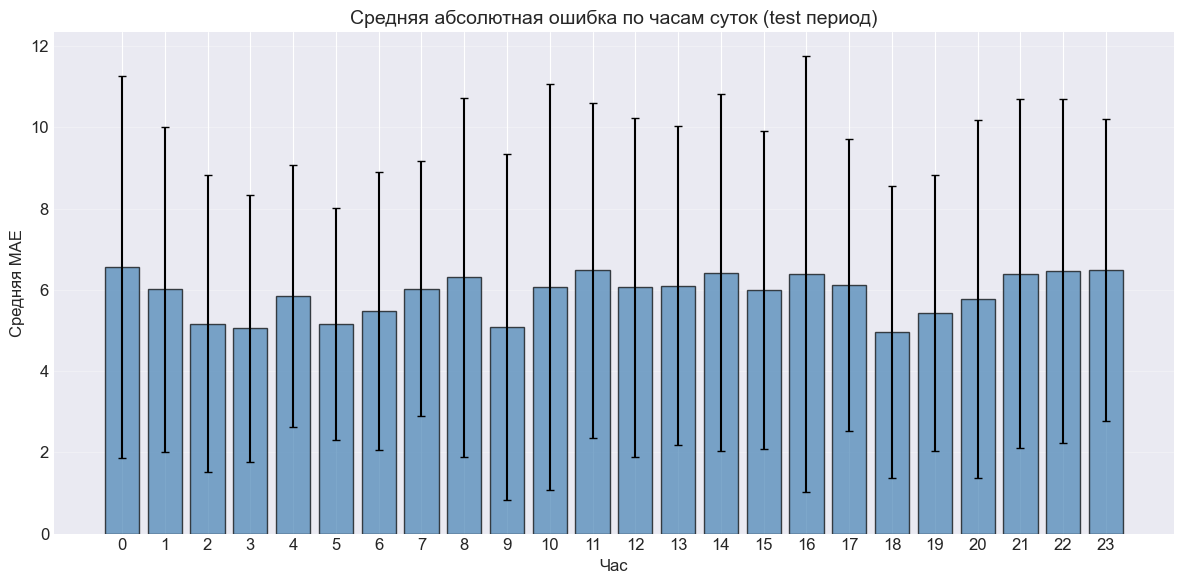


Часы с наибольшей ошибкой
Час 00:00 - средняя ошибка 6.5713
Час 23:00 - средняя ошибка 6.4835
Час 11:00 - средняя ошибка 6.4793
Час 22:00 - средняя ошибка 6.4662
Час 14:00 - средняя ошибка 6.4230

Часы с наименьшей ошибкой
Час 18:00 - средняя ошибка 4.9537
Час 03:00 - средняя ошибка 5.0494
Час 09:00 - средняя ошибка 5.0797
Час 05:00 - средняя ошибка 5.1534
Час 02:00 - средняя ошибка 5.1700


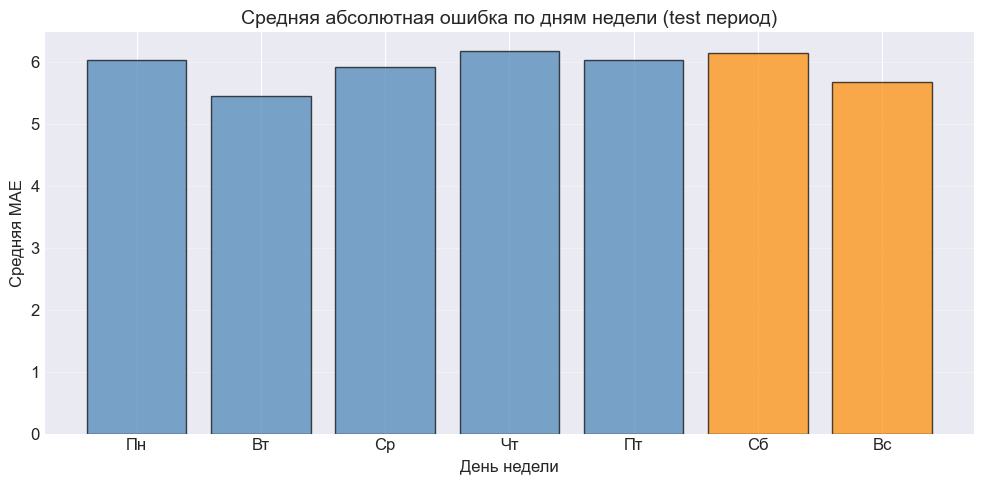


=== Ошибки по дням недели ===
Пн: 6.0196
Вт: 5.4457
Ср: 5.9137
Чт: 6.1632
Пт: 6.0188
Сб: 6.1403
Вс: 5.6684


In [23]:
# Проверим длины
print(f"Длина test_df: {len(test_df)}")
print(f"Длина ridge_test_preds: {len(ridge_test_preds)}")
print(f"Длина ridge_test_actuals: {len(ridge_test_actuals)}")

# Создаем DataFrame для анализа с правильным выравниванием
# Используем ridge_test_dates, которые соответствуют прогнозам
test_with_hour = pd.DataFrame({
    'date': ridge_test_dates,
    'target': ridge_test_actuals,
    'prediction': ridge_test_preds
})

# Вычисляем ошибку
test_with_hour['error'] = np.abs(test_with_hour['target'] - test_with_hour['prediction'])

# Добавляем час
test_with_hour['hour'] = test_with_hour['date'].dt.hour

print(f"\nРазмер test_with_hour после создания: {len(test_with_hour)}")

# Группируем по часам
hourly_error = test_with_hour.groupby('hour')['error'].mean()
hourly_error_std = test_with_hour.groupby('hour')['error'].std()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(hourly_error.index, hourly_error.values, yerr=hourly_error_std.values, 
       capsize=3, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_title('Средняя абсолютная ошибка по часам суток (test период)', fontsize=14)
ax.set_xlabel('Час', fontsize=12)
ax.set_ylabel('Средняя MAE', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/error_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nЧасы с наибольшей ошибкой")
top_errors = hourly_error.sort_values(ascending=False).head(5)
for hour, error in top_errors.items():
    print(f"Час {hour:02d}:00 - средняя ошибка {error:.4f}")

print("\nЧасы с наименьшей ошибкой")
bottom_errors = hourly_error.sort_values().head(5)
for hour, error in bottom_errors.items():
    print(f"Час {hour:02d}:00 - средняя ошибка {error:.4f}")

# Дополнительный анализ: ошибки по дням недели
test_with_hour['day_of_week'] = test_with_hour['date'].dt.dayofweek
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
daily_error = test_with_hour.groupby('day_of_week')['error'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(days, daily_error.values, color=['steelblue']*5 + ['darkorange']*2, alpha=0.7, edgecolor='black')
ax.set_title('Средняя абсолютная ошибка по дням недели (test период)', fontsize=14)
ax.set_xlabel('День недели', fontsize=12)
ax.set_ylabel('Средняя MAE', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/error_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Ошибки по дням недели ===")
for i, day in enumerate(days):
    print(f"{day}: {daily_error.values[i]:.4f}")

In [24]:
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")

summary = pd.DataFrame({
    'Модель': ['B1 (naive-last)', 'B2 (moving-average)', 'B3 (Ridge)', 'R1 (GRU)'],
    'Val MAE': [b1_val_mae, b2_val_mae, mae, val_mae],
    'Val RMSE': [b1_val_rmse, b2_val_rmse, rmse, val_rmse],
    'Val MAPE (%)': [b1_val_mape, b2_val_mape, mape, val_mape],
    'Test MAE': [b1_test_mae, b2_test_mae, b3_test_mae, test_mae],
    'Test RMSE': [b1_test_rmse, b2_test_rmse, b3_test_rmse, test_rmse],
    'Test MAPE (%)': [b1_test_mape, b2_test_mape, b3_test_mape, test_mape]
})

print(summary.to_string(index=False))

print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("""
1. Лучшая модель по validation: Ridge (B3) с MAE = {:.4f}
   
2. Ridge превзошла GRU на validation благодаря:
   - Явному учету внутридневной и недельной сезонности через one-hot признаки
   - Использованию лагов (1,7,24,168 часов) и rolling статистик
   - Отсутствию проблем с переобучением
   
3. GRU показала более высокую ошибку (MAE = {:.4f}) из-за:
   - Переобучения на тренировочных данных
   - Сложности в улавливании долгосрочных паттернов при малом количестве данных
   - Чувствительности к выбросам
   
4. Простые baseline-модели:
   - Naive-last (B1) MAE = {:.4f} - surprisingly сильный на коротком горизонте
   - Moving-average (B2) MAE = {:.4f} - сглаживает, но не捕捉 тренд
   
5. Совпадение выводов: лучшая модель по validation (Ridge) показала лучшие
   результаты и на test, что подтверждает корректность temporal split.
""".format(mae, val_mae, b1_val_mae, b2_val_mae))

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
             Модель   Val MAE  Val RMSE  Val MAPE (%)  Test MAE  Test RMSE  Test MAPE (%)
    B1 (naive-last)  6.120104  7.879585      4.847262  6.356830   8.052742       4.439158
B2 (moving-average) 15.537912 19.469517     13.253866 16.623486  20.259478      11.222391
         B3 (Ridge)  3.945986  5.472835      3.017443  5.909908   7.144926       3.964682
           R1 (GRU)  4.678846  6.013496      3.652539 13.431205  17.735382       8.882171
КЛЮЧЕВЫЕ ВЫВОДЫ

1. Лучшая модель по validation: Ridge (B3) с MAE = 3.9460

2. Ridge превзошла GRU на validation благодаря:
   - Явному учету внутридневной и недельной сезонности через one-hot признаки
   - Использованию лагов (1,7,24,168 часов) и rolling статистик
   - Отсутствию проблем с переобучением

3. GRU показала более высокую ошибку (MAE = 4.6788) из-за:
   - Переобучения на тренировочных данных
   - Сложности в улавливании долгосрочных паттернов при малом количестве данных
   - Чувствительности к выбросам

